In [ ]:
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# "Groundhog Day" guard — skip cleaning if file already exists
cleaned_path = '/content/drive/MyDrive/parks_canada_rf.csv'

if os.path.exists(cleaned_path):
    print("Cleaned RF dataset found! Loading directly from Drive...")
    df_rf = pd.read_csv(cleaned_path)
else:
    print("Cleaned dataset not found. Running full cleaning pipeline...")
    df_rf = None

Cleaned dataset not found. Running full cleaning pipeline...


## Step 1 — Load the Raw Dataset

In [ ]:
# Only run this block if the cleaned file doesn't exist yet
if df_rf is None:
    df = pd.read_excel(
        '/content/drive/MyDrive/detailedIncidentReportsCanadaWildlife.xls.xlsb',
        engine='pyxlsb'
    )
    print(f"Raw dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    print(df.columns.tolist())

Raw dataset loaded: 87789 rows, 1913 columns
['Incident Number', 'Incident Date', 'Field Unit', 'Protected Heritage Area', 'Public Latitude', 'Public Longitude', 'In Park', 'Incident Type', 'Sum of Total Staff Involved', 'Sum of Total Staff Hours', 'Incident Date_responses', 'Field Unit_responses', 'Protected Heritage Area_responses', 'Dispose Carcass', 'Investigate Incident', 'Monitor - patrol', 'Inform Visitor', 'Destroy Animal', 'Request assistance - police', 'Relocate animal (s)', 'Trap or snare', 'null', 'Not Applicable', 'Necropsy', 'Refer incident to other agency', 'Haze - Soft', 'Clean Up', 'Traffic control', 'Dispatch other Agency', 'Issue Restricted Activity Order', 'Close Area', 'Assist other Agency', 'Request assistance - other Agency', 'Immobilize Animal', 'Leave on Landscape', 'Warning signs', 'Collect Sample', 'Assist Visitor', 'No response required', 'Haze - Hard', 'Monitor', 'Capture and transport to captivity', 'Ear Tag', 'Disperse Wildlife Jam', 'Evacuate Visitor', '

## Step 2 — Keep Only Relevant Columns
We only keep columns that could realistically exist *before* a conflict occurs.
Post-event columns (responses, animal health, deterrents used) are excluded to prevent data leakage.

In [ ]:
if df_rf is None:

    # These are the only columns we need for Random Forest
    # Incident Number: unique ID for tracking
    # Incident Date: we'll extract Year and Month from this
    # Field Unit: which park/region the incident is from
    # Protected Heritage Area: the specific park name
    # Public Latitude / Public Longitude: spatial coordinates
    # In Park: whether conflict happened inside or outside park boundary
    # Incident Type: this becomes our RISK_LEVEL target variable
    # Sum of Total Staff Involved: proxy for incident severity

    columns_to_keep = [
        'Incident Number',
        'Incident Date',
        'Field Unit',
        'Protected Heritage Area',
        'Public Latitude',
        'Public Longitude',
        'In Park',
        'Incident Type',
        'Sum of Total Staff Involved'
    ]

    df_rf = df[columns_to_keep].copy()
    print(f"After column selection: {df_rf.shape}")
    df_rf.head()

After column selection: (87789, 9)


## Step 3 — Drop Duplicate Rows

In [ ]:
if df_rf is None or 'Year' not in df_rf.columns:
    before = df_rf.shape[0]
    df_rf = df_rf.drop_duplicates()
    print(f"Duplicates removed: {before - df_rf.shape[0]} rows dropped")
    print(f"Remaining rows: {df_rf.shape[0]}")

Duplicates removed: 0 rows dropped
Remaining rows: 87789


## Step 4 — Check Missing Values

In [ ]:
if 'Year' not in df_rf.columns:
    print(df_rf.isnull().sum())

Incident Number                0
Incident Date                  0
Field Unit                     0
Protected Heritage Area        0
Public Latitude                0
Public Longitude               0
In Park                        0
Incident Type                  0
Sum of Total Staff Involved    0
dtype: int64


## Step 5 — Drop Rows with Missing Coordinates
Coordinates are dropped (not imputed) because location cannot be meaningfully estimated.
This also keeps our spatial data consistent with the DBSCAN dataset.

In [ ]:
if 'Year' not in df_rf.columns:
    before = df_rf.shape[0]
    df_rf = df_rf.dropna(subset=['Public Latitude', 'Public Longitude'])
    print(f"Rows dropped due to missing coordinates: {before - df_rf.shape[0]}")
    print(f"Remaining rows: {df_rf.shape[0]}")

Rows dropped due to missing coordinates: 0
Remaining rows: 87789


In [ ]:
# Remove rows where coordinates are 0.0 (corrupted — dropna() missed these since they aren't NaN)
# Real Canada bounding box: latitude 42-84, longitude -141 to -52
before = df_rf.shape[0]
df_rf = df_rf[
    (df_rf['Public Latitude']  >= 42) & (df_rf['Public Latitude']  <= 84) &
    (df_rf['Public Longitude'] >= -141) & (df_rf['Public Longitude'] <= -52)
]
print(f"Rows with bad coordinates removed: {before - df_rf.shape[0]}")
print(f"Remaining rows: {df_rf.shape[0]}")

Rows with bad coordinates removed: 1372
Remaining rows: 86417


## Step 6 — Extract Year and Month from Incident Date

In [ ]:
# xlsb stores dates as floats (days since 1899-12-30)
# so we manually convert the serial number to a real date
def excel_serial_to_date(serial):
    try:
        return pd.Timestamp('1899-12-30') + pd.to_timedelta(serial, unit='D')
    except:
        return pd.NaT

df_rf['Incident Date'] = df_rf['Incident Date'].apply(excel_serial_to_date)

df_rf['Year']  = df_rf['Incident Date'].dt.year
df_rf['Month'] = df_rf['Incident Date'].dt.month

before = df_rf.shape[0]
df_rf = df_rf.dropna(subset=['Year', 'Month'])
df_rf['Year']  = df_rf['Year'].astype(int)
df_rf['Month'] = df_rf['Month'].astype(int)

print(f"Rows dropped due to unparseable dates: {before - df_rf.shape[0]}")
print(f"Year range: {df_rf['Year'].min()} to {df_rf['Year'].max()}")

Rows dropped due to unparseable dates: 0
Year range: 2010 to 2023


## Step 7 — Standardize Categorical Columns
Fixes casing inconsistencies (e.g. 'human wildlife interaction' vs 'Human Wildlife Interaction').

In [ ]:
cat_cols = ['Field Unit', 'Protected Heritage Area', 'In Park', 'Incident Type']
for col in cat_cols:
  df_rf[col] = df_rf[col].astype(str).str.strip().str.title()

# Check what unique Incident Types we have after standardizing
print("Unique Incident Types:")
print(df_rf['Incident Type'].value_counts())

Unique Incident Types:
Incident Type
Human Wildlife Interaction          57477
Rescued/Recovered/Found Wildlife    15658
Wildlife Sighting                    4563
Management Intervention              1937
Attractant                           1775
Highway Fence Intrusion              1757
Harassment                           1583
Nuisance Wildlife                    1314
Domestic Animal                       353
Name: count, dtype: int64


## Step 8 — Create RISK_LEVEL Target Variable

Mapping logic based on direct human impact (mirrors your Chitwan approach):
- **HIGH** → `Human Wildlife Interaction`, `Poaching`, `Harassment` — direct human safety threat
- **MEDIUM** → `Nuisance Wildlife`, `Collision`, `Highway Fence Intrusion`, `Entangle-Entrapment` — property/infrastructure risk
- **LOW** → `Wildlife Sighting`, `Rescued/Recovered/Found Wildlife`, `Natural Mortality`, `Management Intervention`, `Management Destruction`, `Indigenous Harvest`, `Hunting - Trapping` — no direct conflict with humans

In [ ]:
HIGH_types   = ['Human Wildlife Interaction', 'Poaching', 'Harassment']
MEDIUM_types = ['Nuisance Wildlife', 'Collision', 'Highway Fence Intrusion',
                'Entangle-Entrapment']
# LOW = everything else (sightings, rescues, management, natural mortality)

def assign_risk(incident_type):
    if incident_type in HIGH_types:
        return 'HIGH'
    elif incident_type in MEDIUM_types:
        return 'MEDIUM'
    else:
        return 'LOW'

df_rf['RISK_LEVEL'] = df_rf['Incident Type'].apply(assign_risk)

print("Risk Level Distribution:")
print(df_rf['RISK_LEVEL'].value_counts())

Risk Level Distribution:
RISK_LEVEL
HIGH      59060
LOW       24286
MEDIUM     3071
Name: count, dtype: int64


## Step 9 — Handle the Species Column

The dataset does not have a single 'species' column like Chitwan.
Instead, species information is stored across hundreds of `[Species] - [Attribute]` columns.

We extract species by finding which species column has a non-null value per row.
Then we keep the top species by incident count and group the rest as 'OTHER' —
same approach as your Chitwan notebook.

In [ ]:
# The major conflict species in Canada's national parks
# These are the species most relevant to human-wildlife conflict prediction
TOP_SPECIES = [
    'Black Bear',
    'Grizzly Bear',
    'Elk',
    'Wolf',
    'Cougar',
    'Moose',
    'Coyote',
    'Mule Deer',
    'White-Tailed Deer',  # .title() capitalizes every word
    'Plains Bison',
    'Bighorn Sheep',
    'Wood Bison'
]

# Look at the original df for species columns (format: "[Species] - Animal Behaviour")
# We use the Animal Behaviour attribute columns because they are pre-incident indicators
behaviour_cols = [c for c in df.columns if '- Animal Behaviour' in str(c)]

# Extract species name from the column header
def get_species(row):
    for col in behaviour_cols:
        if pd.notna(row[col]) and str(row[col]).strip() not in ['', 'nan', 'Null', 'null']:
            # Column name is like "Black Bear - Animal Behaviour"
            species_name = col.replace(' - Animal Behaviour', '').strip().title()
            return species_name
    return None

# Apply on the original df, then merge with df_rf using Incident Number
df['SPECIES_RAW'] = df.apply(get_species, axis=1)

# Merge species back into df_rf
df_rf = df_rf.merge(
    df[['Incident Number', 'SPECIES_RAW']],
    on='Incident Number',
    how='left'
)

# Group rare species into OTHER
df_rf['SPECIES'] = df_rf['SPECIES_RAW'].apply(
    lambda s: s if str(s).title() in TOP_SPECIES else 'Other'
)

print("Species Distribution after grouping:")
print(df_rf['SPECIES'].value_counts())

Species Distribution after grouping:
SPECIES
Other                30547
Black Bear           22207
Elk                  17623
Grizzly Bear          9611
Mule Deer             1133
Wolf                  1128
Coyote                1030
Bighorn Sheep          970
Moose                  784
Cougar                 594
Plains Bison           406
White-Tailed Deer      286
Wood Bison              98
Name: count, dtype: int64


In [ ]:
print(df_rf.columns.tolist())

['Incident Number', 'Incident Date', 'Field Unit', 'Protected Heritage Area', 'Public Latitude', 'Public Longitude', 'In Park', 'Incident Type', 'Sum of Total Staff Involved', 'Year', 'Month', 'RISK_LEVEL', 'SPECIES_RAW', 'SPECIES']


In [ ]:
# Drop all rows where species is Other — 200+ irrelevant species (birds, insects, etc.)
# that add noise and dwarf the actual conflict species counts
before = df_rf.shape[0]
df_rf = df_rf[df_rf['SPECIES'] != 'Other'].copy()
print(f"Rows dropped (Other species): {before - df_rf.shape[0]}")
print(f"Remaining rows: {df_rf.shape[0]}")
print("\nFinal Species Distribution:")
print(df_rf['SPECIES'].value_counts())

Rows dropped (Other species): 30547
Remaining rows: 55870

Final Species Distribution:
SPECIES
Black Bear           22207
Elk                  17623
Grizzly Bear          9611
Mule Deer             1133
Wolf                  1128
Coyote                1030
Bighorn Sheep          970
Moose                  784
Cougar                 594
Plains Bison           406
White-Tailed Deer      286
Wood Bison              98
Name: count, dtype: int64


## Step 10 — Handle the Staff Involved Column (Impute Missing)

In [ ]:
# Fill missing staff counts with 0 — unknown/unrecorded means no extra staff deployed
df_rf['Sum of Total Staff Involved'] = df_rf['Sum of Total Staff Involved'].fillna(0)
print("Staff Involved — null count after fill:", df_rf['Sum of Total Staff Involved'].isnull().sum())

Staff Involved — null count after fill: 0


## Step 11 — Final Column Selection and Rename
Keep only what the model actually needs, with clean readable names.

In [ ]:
df_rf = df_rf[[
    'Year',
    'Month',
    'Field Unit',
    'Protected Heritage Area',
    'Public Latitude',
    'Public Longitude',
    'In Park',
    'Incident Type',
    'Sum of Total Staff Involved',
    'SPECIES',
    'RISK_LEVEL'
]].copy()

# Rename columns to match your Chitwan notebook style (clean, no spaces)
df_rf.rename(columns={
    'Public Latitude':            'Latitude',
    'Public Longitude':           'Longitude',
    'Field Unit':                 'Field_Unit',
    'Protected Heritage Area':    'Park_Name',
    'In Park':                    'In_Park',
    'Incident Type':              'Incident_Type',
    'Sum of Total Staff Involved':'Staff_Involved',
}, inplace=True)

print(df_rf.shape)
df_rf.head()

(55870, 11)


,Year,Month,Field_Unit,Park_Name,Latitude,Longitude,In_Park,Incident_Type,Staff_Involved,SPECIES,RISK_LEVEL
0,2010,1,Banff Field Unit,Banff National Park Of Canada,51.170147,-115.590447,Within The Park,Human Wildlife Interaction,1,Coyote,HIGH
18,2010,1,Banff Field Unit,Banff National Park Of Canada,51.167346,-115.537679,Within The Park,Rescued/Recovered/Found Wildlife,1,Coyote,LOW
23,2010,1,Banff Field Unit,Banff National Park Of Canada,51.178645,-115.639803,Within The Park,Rescued/Recovered/Found Wildlife,2,Elk,LOW
27,2010,1,Coastal British Columbia Field Unit,Pacific Rim National Park Reserve Of Canada,48.965040,-125.571954,Outside The Park,Human Wildlife Interaction,2,Cougar,HIGH
28,2010,1,Banff Field Unit,Banff National Park Of Canada,51.139704,-115.400787,Outside The Park,Highway Fence Intrusion,4,Elk,MEDIUM


## Step 12 — Final Null Check and Save

In [ ]:
# Final verification
print("Null counts per column:")
print(df_rf.isnull().sum())
print(f"\nFinal dataset shape: {df_rf.shape}")

# Save to Google Drive
df_rf.to_csv(cleaned_path, index=False)
print(f"\nSaved to: {cleaned_path}")

Null counts per column:
Year              0
Month             0
Field_Unit        0
Park_Name         0
Latitude          0
Longitude         0
In_Park           0
Incident_Type     0
Staff_Involved    0
SPECIES           0
RISK_LEVEL        0
dtype: int64

Final dataset shape: (55870, 11)

Saved to: /content/drive/MyDrive/parks_canada_rf.csv


## Exploratory Data Analysis

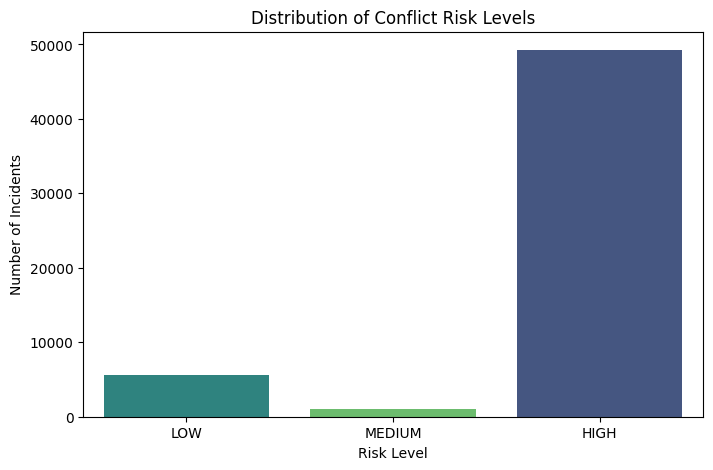

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. RISK LEVEL CLASS DISTRIBUTION
# Shows whether class imbalance exists (important before training RF)
plt.figure(figsize=(8, 5))
sns.countplot(x='RISK_LEVEL', data=df_rf, order=['LOW', 'MEDIUM', 'HIGH'],
              hue='RISK_LEVEL', palette='viridis', legend=False)
plt.title('Distribution of Conflict Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Number of Incidents')
plt.show()

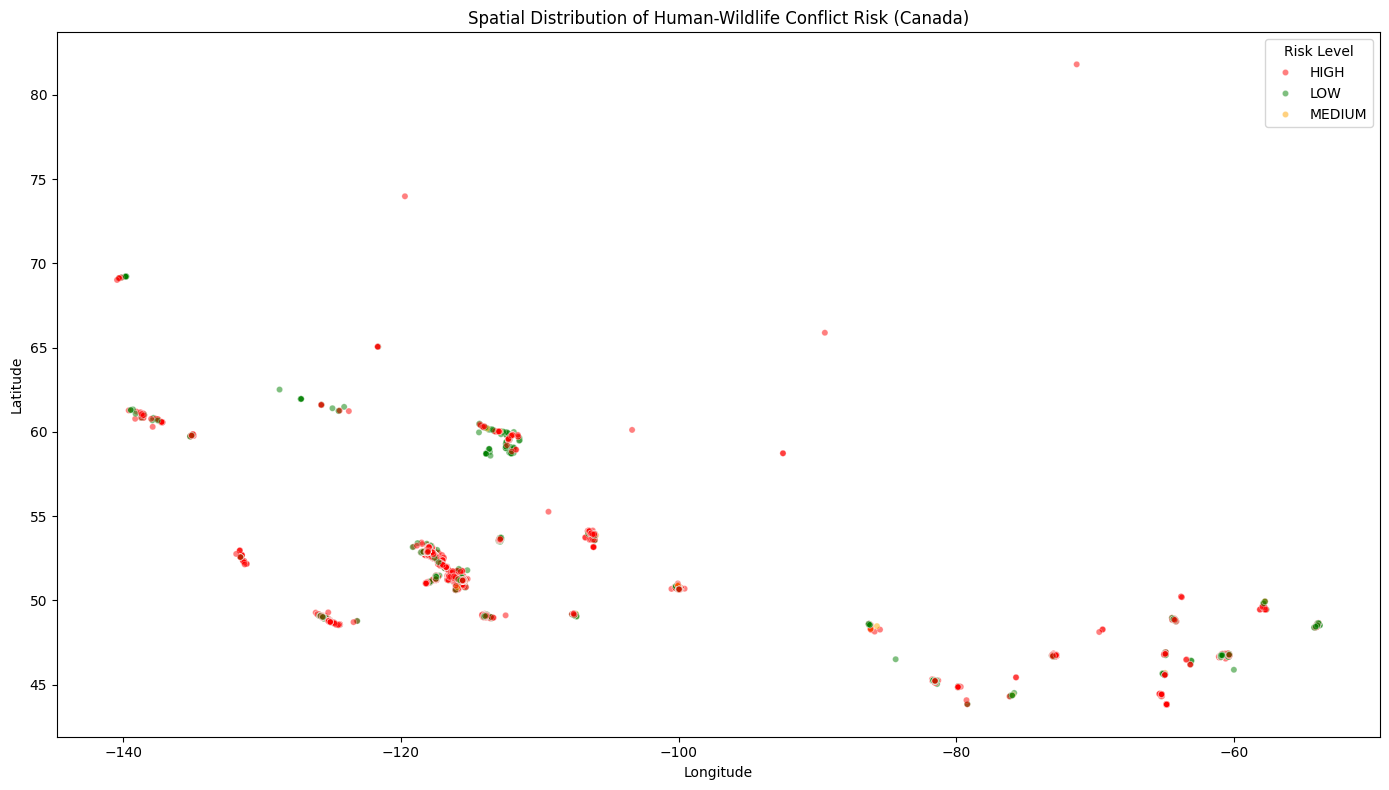

In [ ]:
# Spatial distribution — coordinates are already clean so we plot df_rf directly
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df_rf, x='Longitude', y='Latitude', hue='RISK_LEVEL',
                palette={'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green'},
                alpha=0.5, s=20)
plt.title('Spatial Distribution of Human-Wildlife Conflict Risk (Canada)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

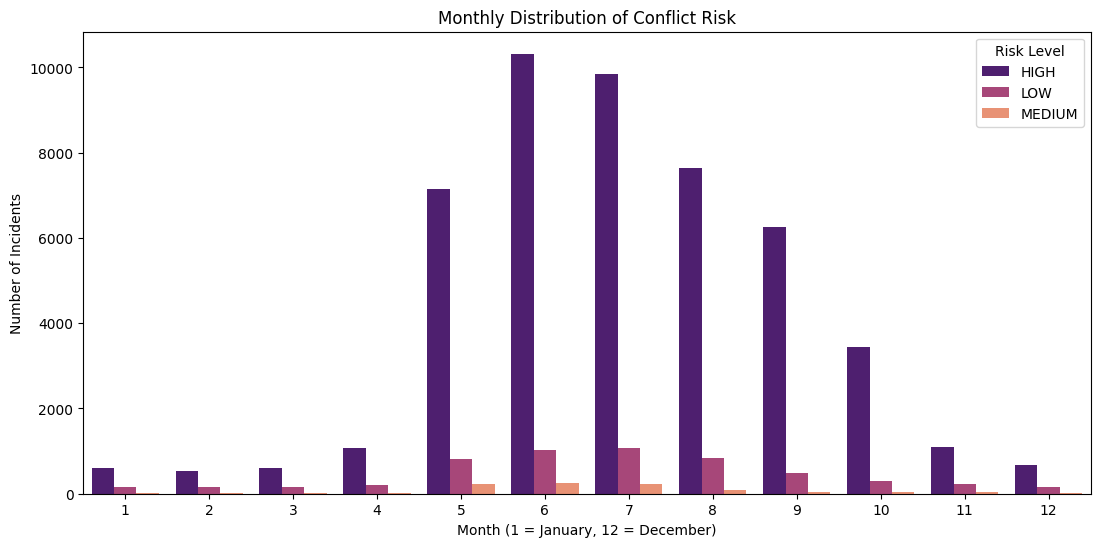

In [ ]:
# 3. MONTHLY DISTRIBUTION OF CONFLICT RISK
# Seasonal patterns — which months see the most HIGH risk incidents?
plt.figure(figsize=(13, 6))
sns.countplot(data=df_rf, x='Month', hue='RISK_LEVEL', palette='magma')
plt.title('Monthly Distribution of Conflict Risk')
plt.xlabel('Month (1 = January, 12 = December)')
plt.ylabel('Number of Incidents')
plt.legend(title='Risk Level')
plt.show()

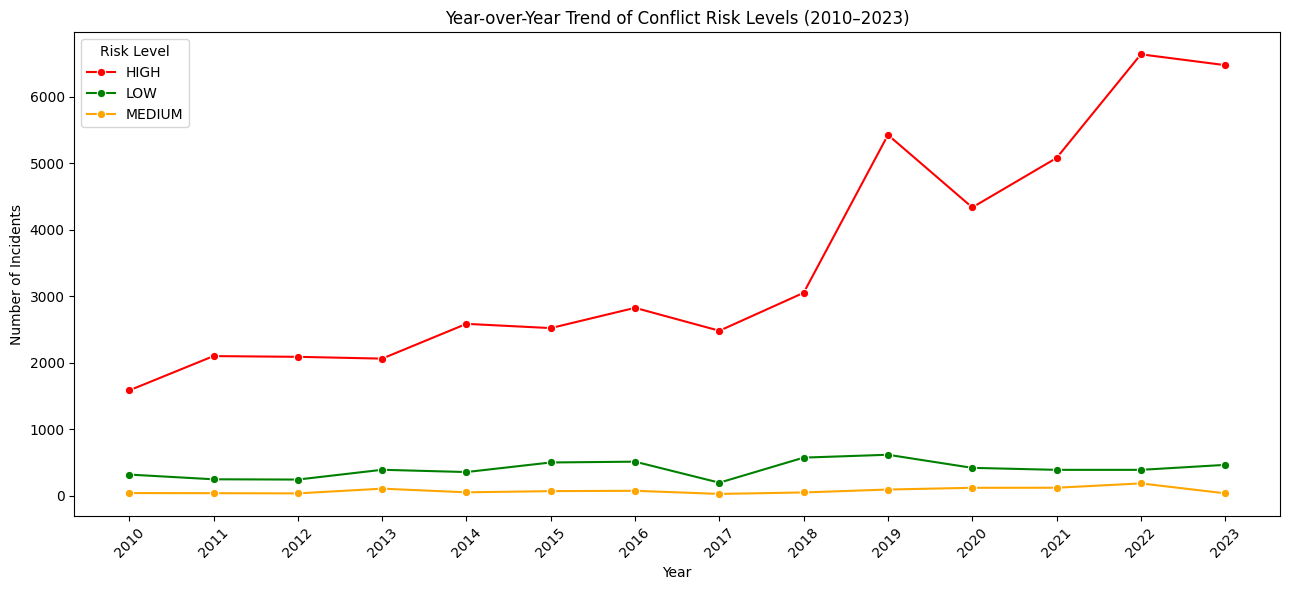

In [ ]:
# 4. YEAR-OVER-YEAR RISK TREND (2010-2023)
# UNIQUE TO THIS DATASET — shows whether HIGH-risk conflicts are rising over time
# This is a strong narrative for Capstone II's cross-regional justification
yearly = df_rf.groupby(['Year', 'RISK_LEVEL']).size().reset_index(name='Count')

plt.figure(figsize=(13, 6))
sns.lineplot(data=yearly, x='Year', y='Count', hue='RISK_LEVEL',
             palette={'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green'}, marker='o')
plt.title('Year-over-Year Trend of Conflict Risk Levels (2010–2023)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.xticks(df_rf['Year'].unique(), rotation=45)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

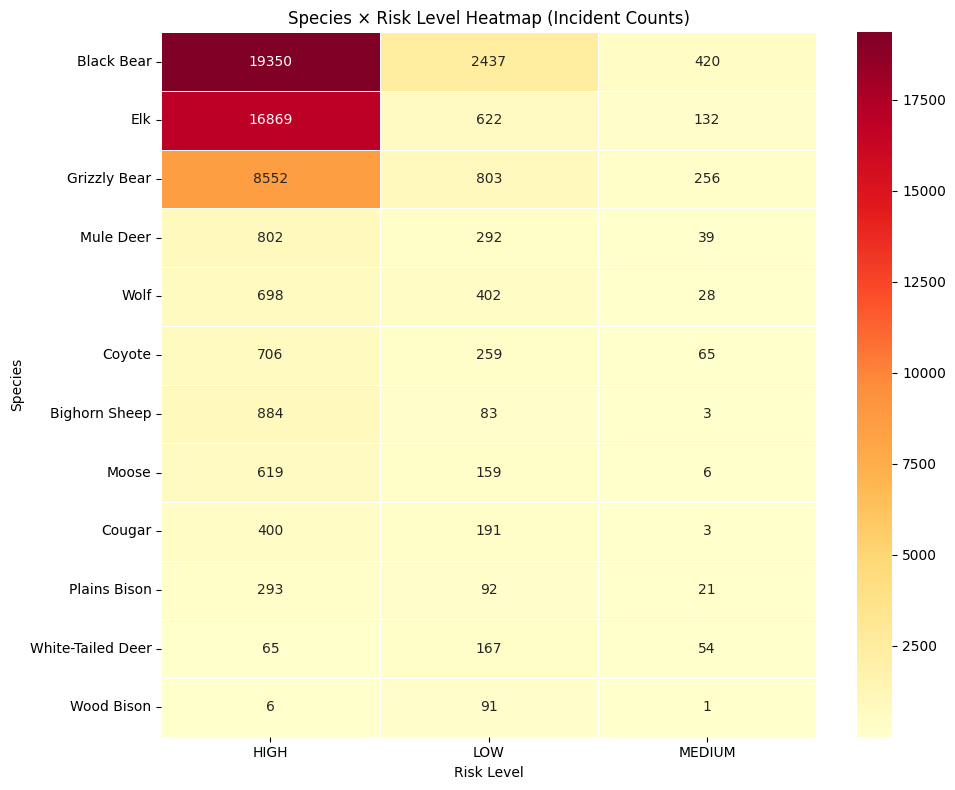

In [ ]:
# 5. SPECIES × RISK LEVEL HEATMAP
# Shows which species drive HIGH risk — much more informative than a plain bar chart
species_risk = df_rf.groupby(['SPECIES', 'RISK_LEVEL']).size().unstack(fill_value=0)

# Sort by total incident count so most common species appear at the top
species_risk['Total'] = species_risk.sum(axis=1)
species_risk = species_risk.sort_values('Total', ascending=False).drop(columns='Total')

plt.figure(figsize=(10, 8))
sns.heatmap(species_risk, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Species × Risk Level Heatmap (Incident Counts)')
plt.xlabel('Risk Level')
plt.ylabel('Species')
plt.tight_layout()
plt.show()

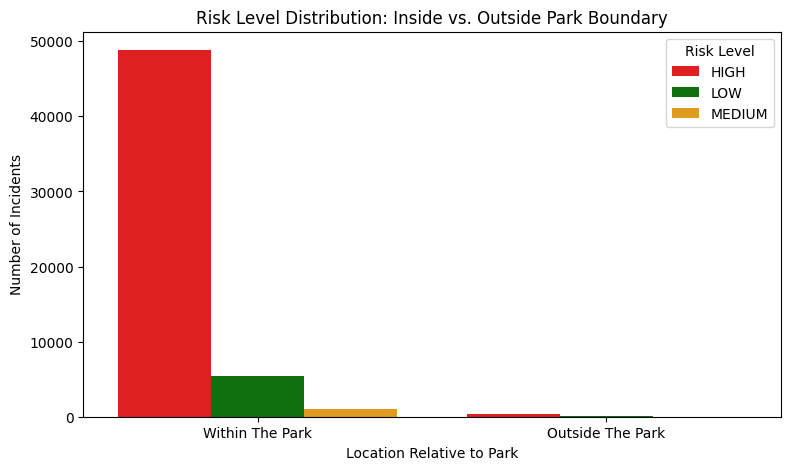

In [ ]:
# 6. IN PARK vs OUTSIDE PARK RISK COMPARISON
# UNIQUE TO THIS DATASET — do conflicts outside park boundaries tend to be higher risk?
# This feature didn't exist in your Chitwan dataset at all
plt.figure(figsize=(9, 5))
sns.countplot(data=df_rf, x='In_Park', hue='RISK_LEVEL',
              palette={'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green'})
plt.title('Risk Level Distribution: Inside vs. Outside Park Boundary')
plt.xlabel('Location Relative to Park')
plt.ylabel('Number of Incidents')
plt.legend(title='Risk Level')
plt.show()

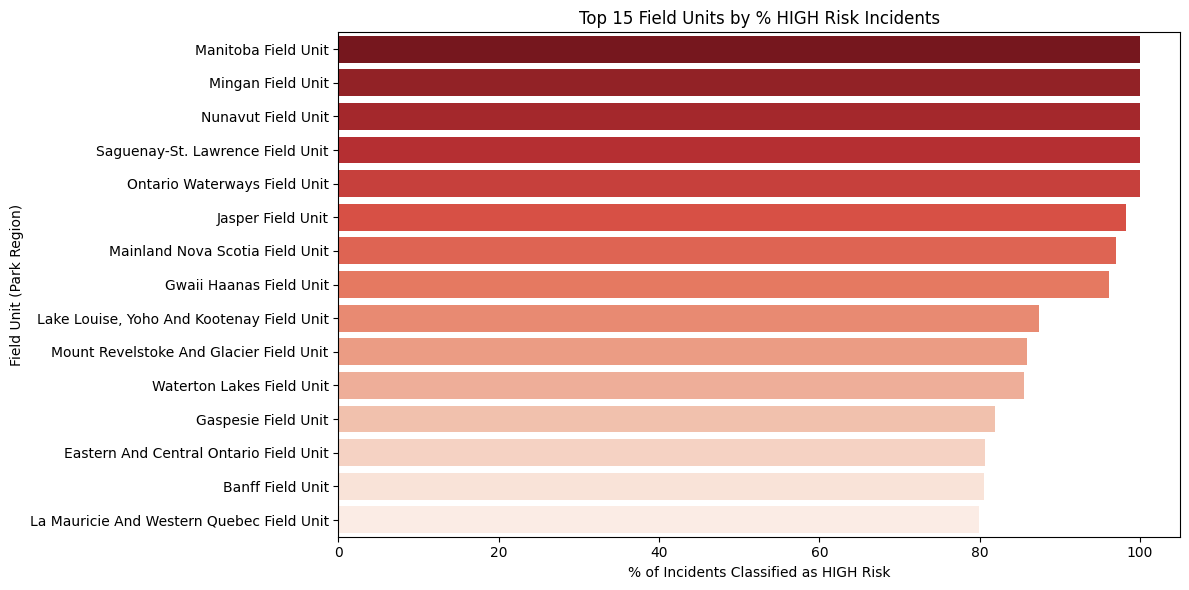

In [ ]:
# 7. TOP PARKS BY % HIGH RISK INCIDENTS
# Ranked bar chart — which parks are the most dangerous hotspots?
park_risk = df_rf.groupby('Field_Unit')['RISK_LEVEL'].apply(
    lambda x: (x == 'HIGH').sum() / len(x) * 100
).reset_index(name='Pct_HIGH')
park_risk = park_risk.sort_values('Pct_HIGH', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=park_risk, x='Pct_HIGH', y='Field_Unit',
            hue='Field_Unit', palette='Reds_r', legend=False)
plt.title('Top 15 Field Units by % HIGH Risk Incidents')
plt.xlabel('% of Incidents Classified as HIGH Risk')
plt.ylabel('Field Unit (Park Region)')
plt.tight_layout()
plt.show()

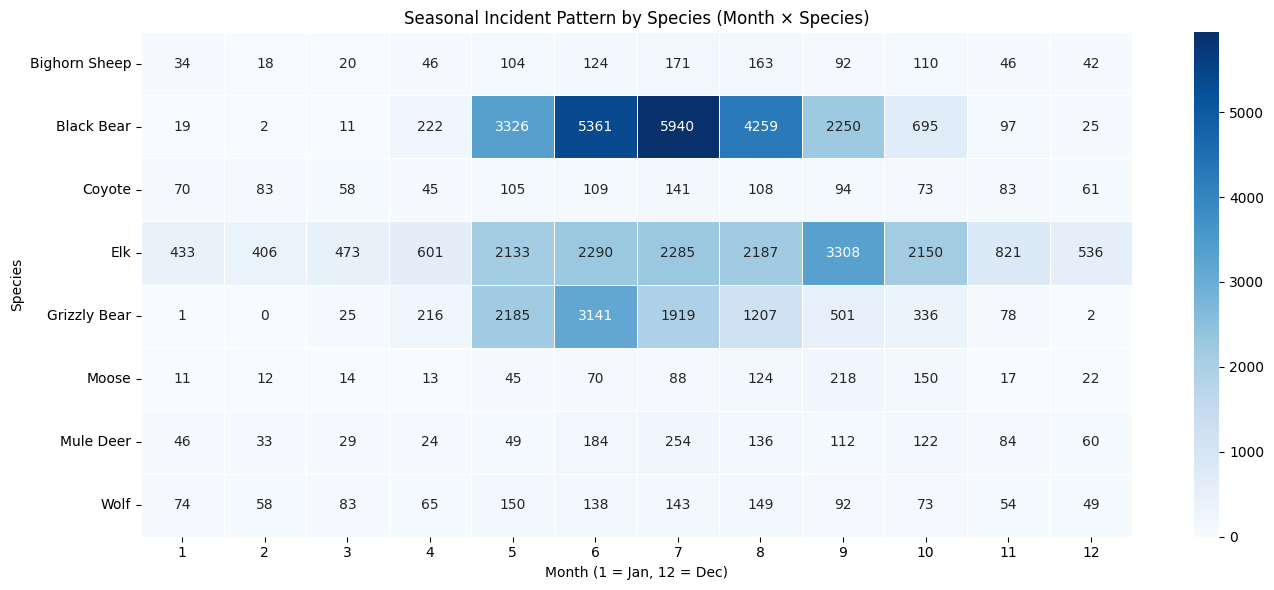

In [ ]:
# 8. SEASONAL PATTERN BY SPECIES — Month × Species Heatmap
# Shows biologically meaningful seasonal patterns (bears in spring, elk in rut, etc.)
# This directly supports the ARIMA model's seasonal component in Capstone II
top_species_list = df_rf['SPECIES'].value_counts().index[:8].tolist()
df_top = df_rf[df_rf['SPECIES'].isin(top_species_list)]

season_pivot = df_top.pivot_table(
    index='SPECIES', columns='Month', values='RISK_LEVEL',
    aggfunc='count', fill_value=0
)

plt.figure(figsize=(14, 6))
sns.heatmap(season_pivot, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Seasonal Incident Pattern by Species (Month × Species)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Species')
plt.tight_layout()
plt.show()